# Figure2(Stackedbar) for bertopic

In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_10): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [2]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.date_setting import Date_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic)
mpl.rcParams['font.family'] = font_setting.init_font()

Helvetica /home/mghan/.fonts/Helvetica/Helvetica Bold Oblique.ttf
Registered font name: Helvetica


In [3]:
color_list = Color_Setting.color_list
alpha_list = [1, 1, 0.7]

In [4]:
viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")

output_dir = create_dir('./fig/')
date_range = 'Weekly'

std_date = Date_Setting[option_dict['year_range']]['std_date']

[Deleteing... ] ./fig/


In [5]:
df = load_df(data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])

In [6]:
df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed").dt.normalize()
# df['cdate'] = pd.to_datetime(df['creationdate'], format="%Y-%m-%d").dt.date
df['rel_week'] = ((df['creationdate'] - std_date).dt.days // 7)
# df.sort_values(by = ['cdate']).reset_index(drop=True, inplace=True)

In [7]:
prop_df = proportion_calc_for_topic(df, 'rel_week', 'Topic')

In [8]:
top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
               'Bottom 20% Topics' : bot10list}


df_dict = {'Top 20% Topics'       : prop_df[prop_df['Topic'].isin(top10list)],   
          'Bottom 20% Topics'     : prop_df[prop_df['Topic'].isin(bot10list)]}

    


In [9]:
# calculate entropy and gini by weekly manner
df_coef = {'Entropy' : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_entropy(x)).to_frame(name='Entropy').reset_index(),
           'Gini'    : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_gini(x)).to_frame(name = 'Gini').reset_index()}

In [10]:
# calculate the proportion weekly manner
# prop_df = pd.merge( df.groupby(['rel_week', 'Topic']).count()['id'].reset_index().rename(columns={'id': 'cnt'}),
#                         df.groupby(['rel_week']).count()['id'].reset_index().rename(columns={'id': 'tot_cnt'}), on = 'rel_week')
# prop_df['proportion'] = prop_df['cnt']/prop_df['tot_cnt']

In [11]:
# topic_list = list(prop_df[prop_df['rel_week'] <0].groupby('Topic').sum()['proportion'].reset_index().sort_values(by = 'proportion', ascending=False)['Topic'])
# top10list = topic_list[:10]
# bot10list = topic_list[-10:]
# mid30list = np.setdiff1d(np.arange(0,50), top10list)
# mid30list = np.setdiff1d(mid30list, bot10list)



In [12]:
plot_gen = PlotGen.PlotGen()

[-52, -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
[-52, -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


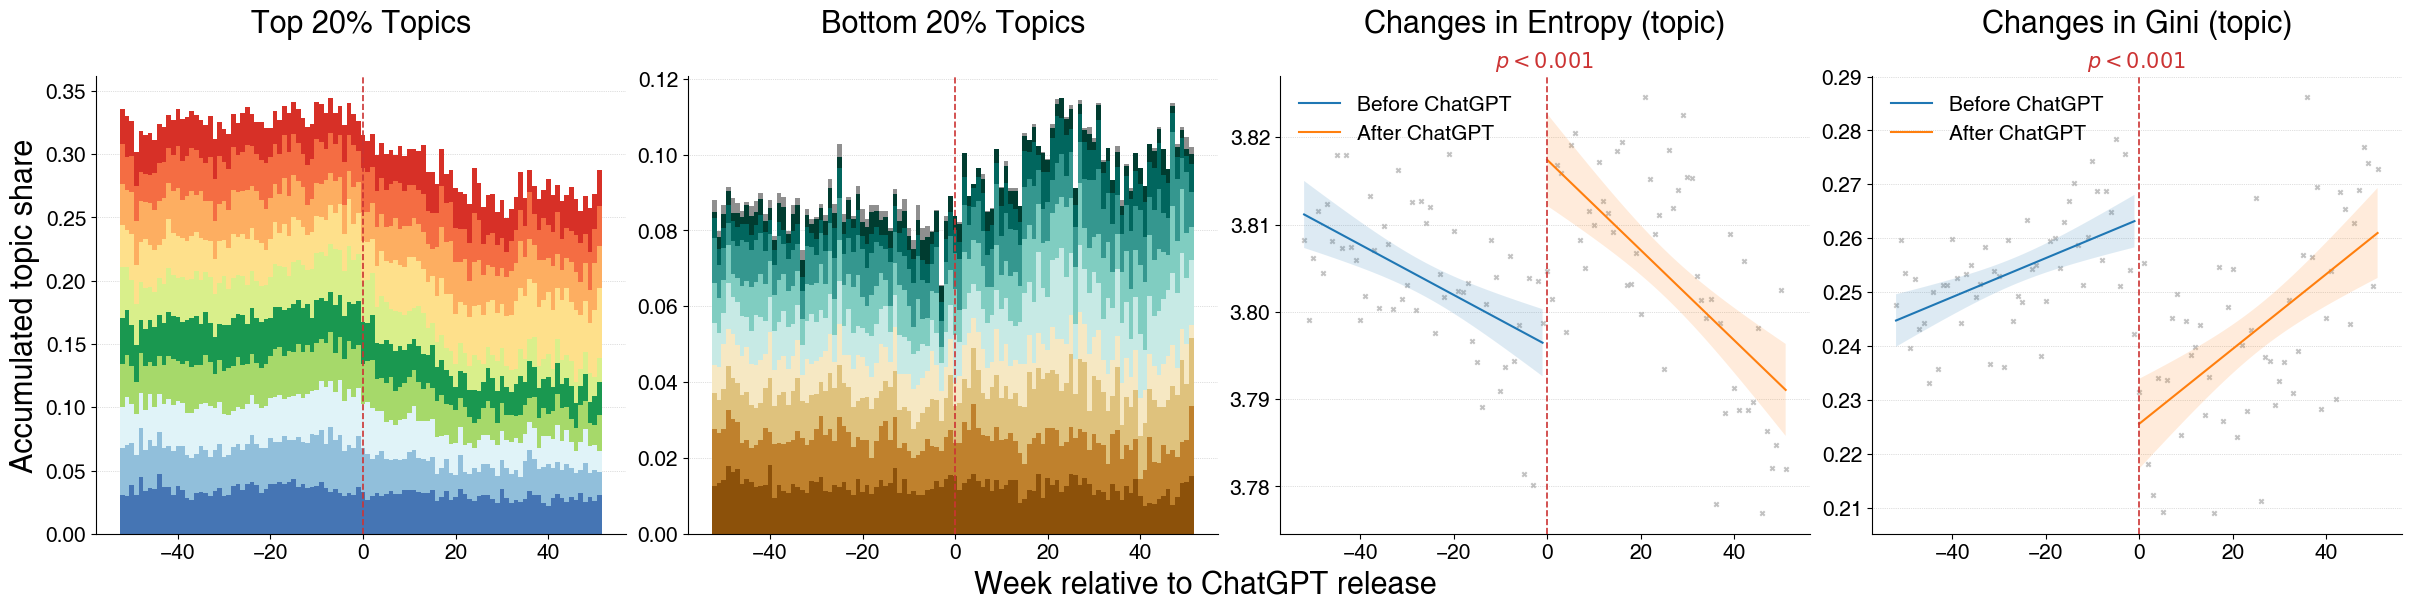

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

### stacked topic plots
for i, (title, proportion) in enumerate(df_dict.items()):

    plot_gen.draw_topic_stack(
        axs[i], # ax
        title, # title
        proportion, # proportion
        list_10[title], # order_list
        color_list[i], # colors
        alpha_list[i], # alpha
        None, # panel_label
    )


axs[0].set_ylabel("Accumulated topic share", fontsize=22)


### regression plots
buff = 2

for j, (title, proportion) in enumerate(df_coef.items()):

    series = proportion[title]

    plot_gen.draw_regression(
        axs[j + buff],
        title,
        series
    )


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)

plt.savefig(f"{output_dir}C_Result_Fig2_2.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
sorted(df_dict['Top 20% Topics']['rel_week'].unique())

[-52,
 -51,
 -50,
 -49,
 -48,
 -47,
 -46,
 -45,
 -44,
 -43,
 -42,
 -41,
 -40,
 -39,
 -38,
 -37,
 -36,
 -35,
 -34,
 -33,
 -32,
 -31,
 -30,
 -29,
 -28,
 -27,
 -26,
 -25,
 -24,
 -23,
 -22,
 -21,
 -20,
 -19,
 -18,
 -17,
 -16,
 -15,
 -14,
 -13,
 -12,
 -11,
 -10,
 -9,
 -8,
 -7,
 -6,
 -5,
 -4,
 -3,
 -2,
 -1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51]

,rel_week,Topic,cnt,tot_cnt,proportion
0,-52,0,156,4647,0.033570
1,-52,1,143,4647,0.030773
2,-52,2,150,4647,0.032279
3,-52,3,174,4647,0.037444
4,-52,4,155,4647,0.033355
...,...,...,...,...,...
5135,51,5,50,1508,0.033156
5136,51,6,39,1508,0.025862
5137,51,7,48,1508,0.031830
5138,51,8,29,1508,0.019231
